In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Estimating volatility in $dX_t = \sigma\,dW_t$

Over one short time step $\Delta t$,

$$\Delta X_i = X_{t_{i+1}} - X_{t_i} = \sigma\sqrt{\Delta t}Z_i, \qquad Z_i\sim N(0,1).$$

Therefore $\Delta X_i\sim N(0,\sigma^2\Delta t)$. The parameter $\sigma$ controls the typical size of the random movement.

In [18]:
rng = np.random.default_rng(1)

def brownian(x_0, sigma, dt, num_steps, rng):
    jumps = rng.normal(size=num_steps)
    increments = sigma * np.sqrt(dt) * jumps
    return np.r_[x_0, x_0 + np.cumsum(increments)]

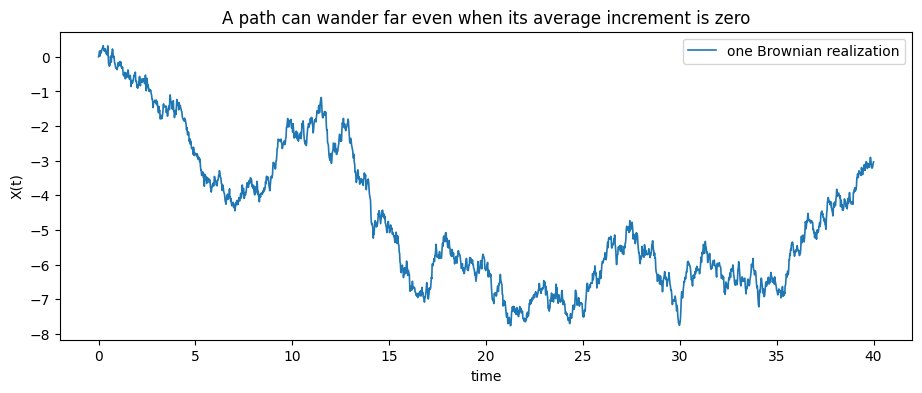

In [ ]:
dt = 0.02
n_steps = 2_000
time = np.arange(n_steps + 1) * dt

brownian_sigma_true = 0.8
brownian_path = brownian(x_0=0.0, sigma=brownian_sigma_true, dt=dt,
                         num_steps=n_steps, rng=rng)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time, brownian_path, lw=1.2, label="one Brownian realization")
ax.set(xlabel="time", ylabel="X(t)", title="Brownian motion realization")
ax.legend();
plt.show()

## Maximum-likelihood estimate of $\sigma$

For the observed increments $y_i=\Delta X_i$, the likelihood is

$$L(\sigma)=\prod_{i=0}^{n-1}\frac{1}{\sqrt{2\pi\sigma^2\Delta t}}\exp\left(-\frac{y_i^2}{2\sigma^2\Delta t}\right).$$

We maximize its logarithm instead, because $\log$ is increasing and changes the product into a sum:

$$\ell(\sigma)=-\frac{n}{2}\log(2\pi\sigma^2\Delta t)-\frac{1}{2\sigma^2\Delta t}\sum_{i=0}^{n-1}y_i^2.$$

Let $v=\sigma^2$. Differentiating with respect to $v$ and setting the result to zero gives

$$0=\frac{d\ell}{dv}=-\frac{n}{2v}+\frac{1}{2v^2\Delta t}\sum_{i=0}^{n-1}y_i^2.$$

Multiplying by $2v^2$ and rearranging:

$$nv=\frac{1}{\Delta t}\sum_{i=0}^{n-1}y_i^2$$

$$\widehat{\sigma^2}=\hat v=\frac{1}{n\Delta t}\sum_{i=0}^{n-1}(\Delta X_i)^2.$$

This estimates $\sigma^2$, not $\sigma$. Since volatility is non-negative, take the positive square root:

$$\boxed{\hat\sigma=\sqrt{\widehat{\sigma^2}}=\sqrt{\frac{1}{n\Delta t}\sum_{i=0}^{n-1}(\Delta X_i)^2}}.$$

In [20]:
# Estimate sigma from the path, as if brownian_sigma_true were unknown.
increments = np.diff(brownian_path)
sigma_hat_squared = np.mean(increments**2) / dt
sigma_hat = np.sqrt(sigma_hat_squared)

print(f"True sigma:              {brownian_sigma_true:.4f}")
print(f"MLE estimate of sigma^2: {sigma_hat_squared:.4f}")
print(f"MLE estimate of sigma:   {sigma_hat:.4f}")

True sigma:              0.8000
MLE estimate of sigma^2: 0.6486
MLE estimate of sigma:   0.8053


In [21]:
# The same calculation written directly from the formula.
sigma_hat_from_formula = np.sqrt(
    np.sum((brownian_path[1:] - brownian_path[:-1])**2) / (n_steps * dt)
)

np.testing.assert_allclose(sigma_hat, sigma_hat_from_formula)
sigma_hat_from_formula

np.float64(0.8053487563578071)

## Distribution matching: true $\sigma$ versus estimated $\hat\sigma$

The histogram shows the increments from the simulated path. The two lines are the normal distributions predicted by the original simulation parameter and by the MLE estimate. In real data, the true $\sigma$ is unknown, so only the $\hat\sigma$ curve is available.

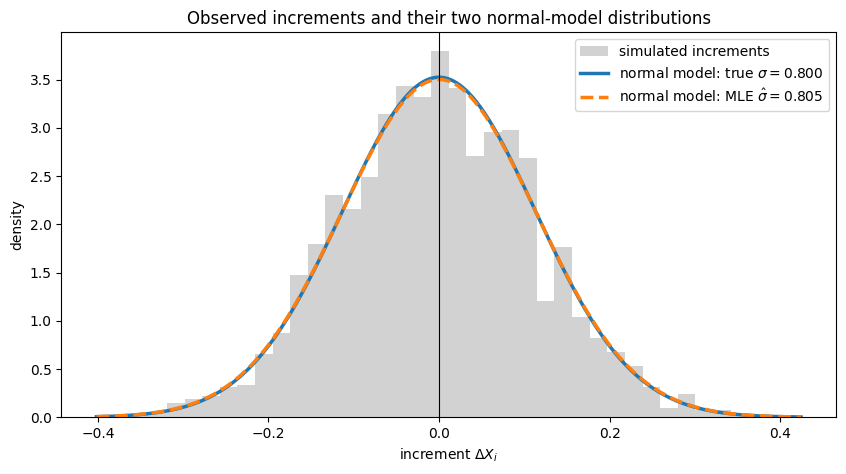

In [22]:
# Each increment has standard deviation sigma * sqrt(dt).
increment_std_true = brownian_sigma_true * np.sqrt(dt)
increment_std_hat = sigma_hat * np.sqrt(dt)

x = np.linspace(increments.min(), increments.max(), 500)
pdf_true = np.exp(-0.5 * (x / increment_std_true)**2) / (increment_std_true * np.sqrt(2 * np.pi))
pdf_hat = np.exp(-0.5 * (x / increment_std_hat)**2) / (increment_std_hat * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(increments, bins=40, density=True, alpha=0.35, color="gray",
        label="simulated increments")
ax.plot(x, pdf_true, lw=2.5, label=fr"normal model: true $\sigma={brownian_sigma_true:.3f}$")
ax.plot(x, pdf_hat, "--", lw=2.5, label=fr"normal model: MLE $\hat{{\sigma}}={sigma_hat:.3f}$")
ax.axvline(0, color="black", lw=0.8)
ax.set(
    xlabel=r"increment $\Delta X_i$",
    ylabel="density",
    title="Observed increments and their two normal-model distributions",
)
ax.legend()
plt.show()

## Harmonic Oscillator

In [23]:
def harmonic_oscillator(omega_0, sigma, x0, v0, dt, n_steps, rng):

    time = np.arange(n_steps + 1) * dt
    position = np.empty(n_steps + 1)
    velocity = np.empty(n_steps + 1)

    position[0] = x0
    velocity[0] = v0

    for i in range(n_steps):
        noise = sigma + np.sqrt(dt) * rng.normal()
        position[i + 1] = position[i] + velocity[i] * dt
        velocity[i + 1] = -(omega_0 ** 2) * position[i] * dt + noise

    return time, position, velocity

In [ ]:
time, pos, vel = harmonic_oscillator(0.2, 0.3, 1.0, 0.0, 0.001, 10000, rng)

fig, ax = plt.subplots(figsize=(10000, 100))
ax.plot(time, pos, lw=1.2, label="Harmonic Oscillator")
ax.set(xlabel="time", ylabel="X(t)", title="A path can wander far even when its average increment is zero")
ax.legend();
plt.show()